In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, HGTConv, HeteroConv
from torch.nn import ParameterDict, Parameter

import pandas as pd
import networkx as nx
import argparse

import os
import sys
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from utils.graph_utils import load_graph, save_graph
from data_processing.network_generator import PatientNetworkGenerator
from utils import sample_scoring
from hetero_base_models.utilities import convert_to_hetero_data

from hetero_base_models.train_hybridkg import (compute_link_loss, 
                            split_edges,
                            evaluate_link,
                            build_x_dict,
                            set_seed
                            )

### Reprocess ADNI data

In [ ]:
adni_exp = pd.read_csv("../AD/data/ADNI/cleaned_gene_expression_data.csv", index_col=0)
adni_design = pd.read_csv("../AD/data/ADNI/design_with_real_target.tsv",sep='\t',index_col=0)
adni_design['Target'] = adni_design['Old_Target'].map({'Control':0, 'Disease':1})

## Hybrid Network Generation
+ Sample ---reg_disease---> ADKG
+ Sample ---reg_healthy---> HealthyKG

In [25]:
adni_kg = load_graph("../datasets/MergedKGs/G_adni_merge_ecdf.pkl")
adni_old_kg = load_graph("../datasets/MergedKGs/G_adni_merge_ecdf_oldTarget.pkl")
geo_kg = load_graph("../datasets/MergedKGs/G_geo_merge_ecdf.pkl")

Loaded graph from ../datasets/MergedKGs/G_adni_merge_ecdf.pkl: 8275 nodes, 109408 edges
Loaded graph from ../datasets/MergedKGs/G_adni_merge_ecdf_oldTarget.pkl: 8564 nodes, 166672 edges
Loaded graph from ../datasets/MergedKGs/G_geo_merge_ecdf.pkl: 8287 nodes, 108456 edges


In [14]:
edge_types = set()
for src, dst, rel, attr in adni_kg.edges(data=True, keys=True):
    if not isinstance(rel, str):
        rel = attr.get('relation')
    edge_types.add(rel)
    # print(src, dst, rel)
    # print(attr)
    # print()
edge_types

{'decreases',
 'directly_decreases',
 'directly_increases',
 'down_reg_disease',
 'down_reg_healthy',
 'has__abundance',
 'has__complex',
 'has__fragment',
 'has__from_location',
 'has__gene',
 'has__location',
 'has__pmod',
 'has__products',
 'has__protein',
 'has__reactants',
 'has__rna',
 'has__to_location',
 'has__variant',
 'has_fragmented_protein',
 'has_located_abundance',
 'has_located_protein',
 'has_located_rna',
 'has_modified_protein',
 'has_variant_gene',
 'has_variant_protein',
 'has_variant_rna',
 'increases',
 'is_a',
 'regulates',
 'rev_decreases',
 'rev_directly_decreases',
 'rev_directly_increases',
 'rev_down_reg_disease',
 'rev_down_reg_healthy',
 'rev_increases',
 'rev_is_a',
 'rev_regulates',
 'rev_up_reg_disease',
 'rev_up_reg_healthy',
 'transcribed_to',
 'translated_to',
 'up_reg_disease',
 'up_reg_healthy'}

## HeteroData Preparation

In [28]:
# Convert networkx to HeteroData
def convert_to_hetero_data(G: nx.MultiDiGraph):
    """
    Converts the hybrid Patient-Protein network into a PyTorch Geometric HeteroData object.
    Initializes features for ALL node types to match Patient feature dimensions.
    """
    print("Starting conversion from NetworkX to HeteroData...")
    data = HeteroData()
    node_mappings = {} # {node_type: {node_name: integer_index}}
    
    # 1. Categorize Nodes and Map Indices
    for node, attrs in G.nodes(data=True):
        n_type = attrs.get('type')
        
        if n_type not in node_mappings:
            node_mappings[n_type] = {}
        
        if node not in node_mappings[n_type]:
            node_mappings[n_type][node] = len(node_mappings[n_type])

    # 2. Process Patient Data (The "Reference" Features)
    p_map = node_mappings.get('Patient', {})
    if not p_map:
        raise ValueError("No 'Patient' nodes found in the graph to use as a feature dimension reference.")
    
    p_ids = sorted(p_map, key=p_map.get)
    patient_x = torch.tensor([G.nodes[pid]['x'] for pid in p_ids], dtype=torch.float)
    
    # Capture the dimension D (e.g., number of genes/features)
    feature_dim = patient_x.size(1) 
    
    data['Patient'].x = patient_x
    data['Patient'].y = torch.tensor([G.nodes[pid]['y'] for pid in p_ids], dtype=torch.long)
    data['Patient'].train_mask = torch.tensor([G.nodes[pid]['train_mask'] for pid in p_ids], dtype=torch.bool)
    data['Patient'].val_mask = torch.tensor([G.nodes[pid]['val_mask'] for pid in p_ids], dtype=torch.bool)
    data['Patient'].test_mask = torch.tensor([G.nodes[pid]['test_mask'] for pid in p_ids], dtype=torch.bool)

    # 3. Process ALL Node Types (Initialize x for all types)
    for n_type, mapping in node_mappings.items():
        if n_type == 'Patient':
            continue  # Already handled above
            
        num_nodes = len(mapping)
        data[n_type].num_nodes = num_nodes
        
        # Initialize features to match Patient feature dimension: use torch.zeros or torch.randn. 
        data[n_type].x = torch.zeros((num_nodes, feature_dim), dtype=torch.float)
        
        #print(f"Initialized {n_type} nodes: {num_nodes} nodes with feature dim {feature_dim}")

    # 4. Process Edges
    edge_stores = {} # {(src_type, rel, dst_type): [[src_idx, dst_idx], ...]}

    for u, v, r, attrs in G.edges(keys=True, data=True):
        u_type = G.nodes[u].get('type')
        v_type = G.nodes[v].get('type')
        if not isinstance(r, str):
            rel = attrs.get('relation')
        else:
            rel = r
        
        # Replace double underscores with single ones to satisfy PyG requirements
        safe_rel = str(rel).replace('__', '_')
        
        edge_type = (u_type, safe_rel, v_type)
        
        if edge_type not in edge_stores:
            edge_stores[edge_type] = []
            
        u_idx = node_mappings[u_type][u]
        v_idx = node_mappings[v_type][v]
        
        edge_stores[edge_type].append([u_idx, v_idx])

    # Finalize Edges in HeteroData
    for etype, content in edge_stores.items():
        data[etype].edge_index = torch.tensor(content, dtype=torch.long).t().contiguous()
    
    print(f"HeteroData created: {len(data.node_types)} node types, {len(data.edge_types)} edge types.")
    return data, node_mappings


In [32]:
data, node_mappings = convert_to_hetero_data(adni_kg)

Starting conversion from NetworkX to HeteroData...


/Users/yuxiaoxuan/master_thesis/HybridKG/hetero_base_models/utilities.py:40: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1719361045918/work/torch/csrc/utils/tensor_new.cpp:277.)
  patient_x = torch.tensor([G.nodes[pid]['x'] for pid in p_ids], dtype=torch.float)


HeteroData created: 25 node types, 819 edge types.


## Gated Model Define

In [36]:
class LinkDecoder(torch.nn.Module):
    """Decoder: Scores edges using relation-specific embeddings."""
    def __init__(self, edge_types, out_channels):
        super().__init__()
        self.rel_emb = ParameterDict({
            "__".join(edge_type): Parameter(torch.empty(out_channels))
            for edge_type in edge_types
        })
        for p in self.rel_emb.values():
            torch.nn.init.xavier_uniform_(p.unsqueeze(0))

    def forward(self, x_dict, edge_type, edge_index):
        src_type, _, dst_type = edge_type
        src_x = x_dict[src_type][edge_index[0]]
        dst_x = x_dict[dst_type][edge_index[1]]
        rel_v = self.rel_emb["__".join(edge_type)]
        return (src_x * rel_v * dst_x).sum(dim=-1) #

class MLPClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.2):
        super().__init__()
        self.dims = [in_channels] + [hidden_channels] * (num_layers - 1) + [out_channels]
        self.layers = torch.nn.ModuleList()
        
        for i in range(len(self.dims) - 1):
            self.layers.append(torch.nn.Linear(self.dims[i], self.dims[i+1]))
            
        self.dropout = dropout

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x

In [39]:
class GatedHeteroEncoder(torch.nn.Module):
    def __init__(self, 
                 data, 
                 model_type, 
                 hidden_channels, 
                 out_channels, 
                 num_layers, 
                 heads, 
                 dropout):
        super().__init__()
        self.model_type = model_type.lower()
        self.dropout = dropout
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        
        # Initial Projections: Samples = x (features), others are initialized as embeddings
        self.input_lin = nn.ModuleDict()
        self.embeddings = torch.nn.ModuleDict()
        for node_type in data.node_types:
            if hasattr(data[node_type], "x") and data[node_type].x is not None:
                in_dim = data[node_type].x.size(-1)
                self.input_lin[node_type] = nn.Linear(in_dim, hidden_channels)
            else:
                self.embeddings[node_type] = torch.nn.Embedding(
                    data[node_type].num_nodes,
                    hidden_channels
                )
        # Conv Layers
        self.convs = torch.nn.ModuleList()
        
        for i in range(num_layers):
            in_ch = hidden_channels if i > 0 else -1 # -1 handles lazy initialization
            curr_out = out_channels if i == num_layers - 1 else hidden_channels
            curr_heads = 1 if i == num_layers - 1 else heads

            if self.model_type == 'gat':
                conv = HeteroConv({
                    edge_type: GATConv(in_ch, curr_out // curr_heads, heads=curr_heads, add_self_loops=False)
                    for edge_type in data.edge_types
                }, aggr='sum')

            elif self.model_type == 'hgt':
                conv = HGTConv(in_ch, curr_out, data.metadata(), heads=curr_heads)
            else:
                raise ValueError("model_type must be 'gat' or 'hgt'")
            
            self.convs.append(conv)
        
        # Gate parameter
        self.gate_lin = nn.Linear(hidden_channels,1)

    def forward(self, x_dict, edge_index_dict):
        # 1. Process x_dict: Use embeddings if x_dict is empty or nodes missing features
        new_x_dict = {}

        for node_type in set(self.embeddings.keys()) | set(self.input_lin.keys()):
            if node_type in x_dict and x_dict[node_type] is not None:
                # has real features → project
                new_x_dict[node_type] = self.input_lin[node_type](x_dict[node_type])
            else:
                # no features → use embedding
                new_x_dict[node_type] = self.embeddings[node_type].weight

        x_dict = new_x_dict

        # 2. Identify disease/healthy contextual edges
        disease_entry_edges = [et for et in edge_index_dict.keys() if "disease" in et[1]]
        healthy_entry_edges = [et for et in edge_index_dict.keys() if "healthy" in et[1]]
        
        # All other biological edges (Shared)
        shared_edges = [et for et in edge_index_dict.keys() 
                        if "disease" not in et[1] and "healthy" not in et[1]]

        # 3. Meassage Aggreagation through ConvLayers
        for i, conv in enumerate(self.convs):
            # --- DISEASE VIEW ---
            # Use shared biology + disease entry points
            d_edges = {et: edge_index_dict[et] for et in (shared_edges + disease_entry_edges)}
            h_dis = conv(x_dict, d_edges)

            # --- HEALTHY VIEW ---
            # Use shared biology + healthy entry points
            h_edges = {et: edge_index_dict[et] for et in (shared_edges + healthy_entry_edges)}
            h_hea = conv(x_dict, h_edges)

            # --- GATED FUSION (At Sample Node Level) ---
            alpha = torch.sigmoid(self.gate_lin(x_dict['Patient']))
            self.alpha = alpha
            # Fuse only the Sample embeddings
            fused_sample = alpha * h_dis['Patient'] + (1 - alpha) * h_hea['Patient']
            
            # Update x_dict: other nodes get the average signal
            new_x_dict = {}
            for n_type in x_dict.keys():
                if n_type == 'Patient':
                    new_x_dict[n_type] = fused_sample
                else:
                    # Update biological nodes with the mean of both views
                    new_x_dict[n_type] = (h_dis[n_type] + h_hea[n_type]) / 2

            x_dict = {k: F.dropout(F.elu(v), p=self.dropout, training=self.training) 
                      for k, v in new_x_dict.items()}

        return x_dict

In [38]:
class GatedModel(torch.nn.Module):
    def __init__(self, 
                 data, 
                 model_type, 
                 hidden_channels, 
                 out_channels, 
                 num_layers, 
                 heads, 
                 dropout,
                 num_classes):
        super().__init__()
        self.encoder = GatedHeteroEncoder(data=data,
                                          model_type=model_type,
                                          hidden_channels= hidden_channels,
                                          out_channels = out_channels, 
                                          num_layers=num_layers, 
                                          heads = heads,
                                          dropout=dropout)
        
        self.classifier = MLPClassifier(
            in_channels=out_channels, 
            hidden_channels=hidden_channels,
            out_channels=num_classes,
            num_layers=num_layers,
            dropout=dropout
        )
        
        self.decoder = LinkDecoder(edge_types=data.edge_types, 
                                    out_channels=out_channels)

    def encode(self, x_dict, edge_index_dict):
        # Get gated embeddings
        h_dict= self.encoder(x_dict, edge_index_dict)
        last_alpha = self.encoder.alpha
        return h_dict, last_alpha

    def classify(self, x_dict):
        return self.classifier(x_dict['Patient'])

    def decode(self, h_dict, edge_type, edge_index):
        # Used for Link Prediction loss
        return self.decoder(h_dict, edge_type, edge_index)

In [72]:
config = {
'graph_path': "../datasets/MergedKGs/G_adni_merge_ecdf.pkl",
'output_dir': "../results/GatedHeteroMLP",
'model':'gat',
'hidden_channels': 128,
'out_channels': 64,
'num_layers': 3,
'heads': 4,
'dropout': 0.3,
'epochs': 100,
'lr': 1e-3,
'weight_decay': 1e-5,
'lambda_link': 0.2,
'val_ratio': 0.15,
'test_ratio':0.15,
'seed':42,
'device': 'cuda',
'assign_method':'cls',
'confidence': 0.6
}
# convert config to Namespace
args = argparse.Namespace(**config)

In [77]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate(model, data, device, train_edge_index_dict, split="val"):
    model.eval()

    with torch.no_grad():
        x_dict = {k: v.to(device) for k, v in data.x_dict.items()}
        train_edge_index_dict = {
        k: v.to(device) for k, v in train_edge_index_dict.items()
        }
        # forward: encode ONLY with TRAIN edges
        z_dict, alpha = model.encode(x_dict, train_edge_index_dict)
        logits = model.classify(z_dict)

    y = data["Patient"].y.to(device)
    mask = data["Patient"][f"{split}_mask"]

    logits = logits[mask]
    y = y[mask]
    num_classes = logits.size(-1)

    y_np = y.cpu().numpy()

    # evaluate alpha matching with labels
    gate_preds = (alpha[mask] > 0.5).float()
    gate_correct = (gate_preds == y).float().mean().item()

    # Binary classification
    if num_classes == 1:
            # Single output neuron case
            probs = torch.sigmoid(logits).cpu().numpy().squeeze()
            preds = (probs > 0.5).astype(int)
            auroc = roc_auc_score(y_np, probs)
            auprc = average_precision_score(y_np, probs)
    else:
        # Multi-class OR 2-neuron binary case
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=1)
        
        if num_classes == 2:
            # FIX: For 2 classes, sklearn wants only the prob of the positive class
            auroc = roc_auc_score(y_np, probs[:, 1])
            auprc = average_precision_score(y_np, probs[:, 1])
        else:
            # Multi-class
            auroc = roc_auc_score(y_np, probs, multi_class="ovr", average="macro")
            auprc = average_precision_score(y_np, probs, average="macro")

    results = {
            "Accuracy": float(accuracy_score(y_np, preds)),
            "F1_score": float(f1_score(y_np, preds, average="macro")),
            "AUROC": float(auroc),
            "AUPRC": float(auprc),
            "Alpha_Alignment": gate_correct, # New Metric: 1.0 is perfect logic
            "avg_alpha": float(alpha[mask].mean()) # Average focus of the model
        }
    return results

def train_one_epoch(
                    model,
                    data,
                    train_edge_index_dict,
                    optimizer,
                    device,
                    lambda_link=0.5,
                    neg_ratio=1.0
                ):
    model.train()
    optimizer.zero_grad()

    # move data
    x_dict = {k: v.to(device) for k, v in data.x_dict.items()}
    #edge_index_dict = {k: v.to(device) for k, v in data.edge_index_dict.items()}
    train_edge_index_dict = {
        k: v.to(device) for k, v in train_edge_index_dict.items()
    }
    # forward: encode ONLY with TRAIN edges
    z_dict, alpha = model.encode(x_dict, train_edge_index_dict)

    # 1. Classification loss
    logits = model.classify(z_dict)

    y = data["Patient"].y.to(device)
    train_mask = data["Patient"].train_mask

    if logits.size(-1) == 1:
        cls_loss = F.binary_cross_entropy_with_logits(
            logits[train_mask].squeeze(),
            y[train_mask].float()
        )
    else:
        cls_loss = F.cross_entropy(
            logits[train_mask],
            y[train_mask]
        )
    # 2. Gate Supervision
    gate_target = y[train_mask].float().unsqueeze(1) 
    gate_loss = F.binary_cross_entropy(alpha[train_mask], gate_target)

    # 3. Link prediction loss
    num_nodes_dict = {
        node_type: data[node_type].num_nodes
        for node_type in data.node_types
    }

    link_loss = compute_link_loss(
        model,
        z_dict,
        train_edge_index_dict,
        num_nodes_dict,
        device,
        neg_ratio=neg_ratio
    )

    # 4. Joint loss
    loss = (1 - lambda_link) * cls_loss + lambda_link * link_loss + 0.5 * gate_loss

    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "cls_loss": cls_loss.item(),
        "gate_loss": gate_loss.item(), # Monitor this!
        "link_loss": link_loss.item()
    }

def train(
            model,
            data,
            train_edges,
            val_edges,
            optimizer,
            device,
            epochs=100,
            lambda_link=0.5
        ):
    
    best_val = 0
    best_state = None
    train_history = {}

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        factor=0.5, 
        patience=10, 
        verbose=True
    )
    for epoch in tqdm(range(epochs), desc="Training HeteoGNN"):
        epoch_history = {}
        losses = train_one_epoch(
                                                    model,
                                                    data,
                                                    train_edges,
                                                    optimizer,
                                                    device,
                                                    lambda_link=lambda_link
                                                )

        val_metrics = evaluate(
                                                model,
                                                data,
                                                device,
                                                train_edge_index_dict=train_edges,
                                                split="val"
                                            )
        
        scheduler.step(val_metrics["F1_score"])

        epoch_history['loss'] = losses
        epoch_history['validation'] = val_metrics
        train_history[epoch] = epoch_history

        if val_metrics["F1_score"] > best_val:
            best_val = val_metrics["F1_score"]
            best_state = model.state_dict()
        

        print(f"Epoch {epoch} | {losses} | Val {val_metrics}")
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_history

def test(model, data, train_edges, test_edges, device):
    
    cls_metrics = evaluate(
        model,
        data,
        device,
        train_edge_index_dict=train_edges,
        split="test"
    )
    
    return cls_metrics

In [76]:
import pickle
from tqdm import tqdm

# Setup
set_seed(args.seed)
device = torch.device(args.device if torch.cuda.is_available() else "cpu")

# 1. Prepare HeteroData
with open(args.graph_path, "rb") as f:
    G = pickle.load(f)
data, node_mappings = convert_to_hetero_data(G)

# Build features
data.x_dict = build_x_dict(data)

# 2. Edge split
edge_index_dict = {
    etype: data[etype].edge_index
    for etype in data.edge_types
}
train_edges, val_edges, test_edges = split_edges(
    edge_index_dict,
    val_ratio=args.val_ratio,
    test_ratio=args.test_ratio,
    seed=args.seed
)
# Labels
y = data["Patient"].y
num_classes = int(y.max().item() + 1) if y.dim() == 1 else y.size(-1)
print(f"Number of classes: {num_classes}")

# 3. model is built
model = GatedModel(data=data,
                   model_type = args.model,
                   hidden_channels=args.hidden_channels, 
                   out_channels=args.out_channels, 
                   num_layers=args.num_layers, 
                   heads=args.heads, 
                   dropout=args.dropout,
                   num_classes=2)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=args.lr,
    weight_decay=args.weight_decay
    )

Starting conversion from NetworkX to HeteroData...
HeteroData created: 25 node types, 819 edge types.
Number of classes: 2


In [78]:
# 4. train
print("\nStart training...\n")
args.lambda_link = 0.0
print(f"lambda_link = {args.lambda_link}")

model, train_history = train(
    model=model,
    data=data,
    train_edges=train_edges,
    val_edges=val_edges,
    optimizer=optimizer,
    device=device,
    epochs=args.epochs,
    lambda_link=args.lambda_link
)

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "



Start training...

lambda_link = 0.0


Training HeteoGNN:   1%|          | 1/100 [00:35<58:46, 35.63s/it]

Epoch 0 | {'loss': 1.0404541492462158, 'cls_loss': 0.694661557674408, 'gate_loss': 0.6915853023529053, 'link_loss': 0.7058226466178894} | Val {'Accuracy': 0.5, 'F1_score': 0.4415458937198068, 'AUROC': 0.501736111111111, 'AUPRC': 0.5592184730743548, 'Alpha_Alignment': 0.529411792755127, 'avg_alpha': 0.9993157386779785}


Training HeteoGNN:   2%|▏         | 2/100 [01:19<1:05:38, 40.19s/it]

...

Epoch 97 | {'loss': 1.027952790260315, 'cls_loss': 0.6722959876060486, 'gate_loss': 0.7113136649131775, 'link_loss': 24.591615676879883} | Val {'Accuracy': 0.5, 'F1_score': 0.45265151515151514, 'AUROC': 0.4939236111111111, 'AUPRC': 0.581483530880806, 'Alpha_Alignment': 0.5242214798927307, 'avg_alpha': 0.5082910656929016}


Training HeteoGNN:  99%|█████████▉| 99/100 [48:27<00:29, 29.36s/it]

Epoch 98 | {'loss': 1.0235029458999634, 'cls_loss': 0.6666772961616516, 'gate_loss': 0.7136512398719788, 'link_loss': 23.110210418701172} | Val {'Accuracy': 0.5, 'F1_score': 0.45265151515151514, 'AUROC': 0.4939236111111111, 'AUPRC': 0.581483530880806, 'Alpha_Alignment': 0.5242214798927307, 'avg_alpha': 0.5083909034729004}


Training HeteoGNN: 100%|██████████| 100/100 [48:58<00:00, 29.38s/it]

Epoch 99 | {'loss': 1.0337657928466797, 'cls_loss': 0.6693143248558044, 'gate_loss': 0.7289029359817505, 'link_loss': 20.71160125732422} | Val {'Accuracy': 0.5, 'F1_score': 0.45265151515151514, 'AUROC': 0.4939236111111111, 'AUPRC': 0.581483530880806, 'Alpha_Alignment': 0.525086522102356, 'avg_alpha': 0.5085384845733643}


In [75]:
# 4. train
print("\nStart training...\n")
print(f"lambda_link = {args.lambda_link}")

model, train_history = train(
    model=model,
    data=data,
    train_edges=train_edges,
    val_edges=val_edges,
    optimizer=optimizer,
    device=device,
    epochs=args.epochs,
    lambda_link=args.lambda_link
)

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "



Start training...

lambda_link = 0.2


Training HeteoGNN:   1%|          | 1/100 [00:35<57:54, 35.09s/it]

Epoch 0 | {'loss': 1.734271764755249, 'cls_loss': 0.694661557674408, 'gate_loss': 0.6915853023529053, 'link_loss': 0.7058226466178894} | Val {'Accuracy': 0.4852941176470588, 'F1_score': 0.44170771756978655, 'AUROC': 0.4730902777777778, 'AUPRC': 0.5031712305250642, 'Alpha_Alignment': 0.529411792755127, 'avg_alpha': 0.9972196221351624}


Training HeteoGNN:   2%|▏         | 2/100 [01:06<53:33, 32.79s/it]

...

Epoch 97 | {'loss': 1.7208613157272339, 'cls_loss': 0.6886986494064331, 'gate_loss': 0.670209527015686, 'link_loss': 0.8229402899742126} | Val {'Accuracy': 0.5294117647058824, 'F1_score': 0.34615384615384615, 'AUROC': 0.4782986111111111, 'AUPRC': 0.5224091338708938, 'Alpha_Alignment': 0.5285466909408569, 'avg_alpha': 0.5386938452720642}


Training HeteoGNN:  99%|█████████▉| 99/100 [45:45<00:26, 26.00s/it]

Epoch 98 | {'loss': 1.742821455001831, 'cls_loss': 0.6897756457328796, 'gate_loss': 0.6857317090034485, 'link_loss': 0.8120167255401611} | Val {'Accuracy': 0.5294117647058824, 'F1_score': 0.34615384615384615, 'AUROC': 0.47916666666666663, 'AUPRC': 0.5228052519140707, 'Alpha_Alignment': 0.5285466909408569, 'avg_alpha': 0.5387945175170898}


Training HeteoGNN: 100%|██████████| 100/100 [46:09<00:00, 27.70s/it]

Epoch 99 | {'loss': 1.7491497993469238, 'cls_loss': 0.6924406886100769, 'gate_loss': 0.6891478300094604, 'link_loss': 0.8073777556419373} | Val {'Accuracy': 0.5294117647058824, 'F1_score': 0.34615384615384615, 'AUROC': 0.47916666666666663, 'AUPRC': 0.5228052519140707, 'Alpha_Alignment': 0.5285466909408569, 'avg_alpha': 0.538984477519989}


In [69]:
test_metrics = test(model, data, train_edges, test_edges, device)
test_metrics

{'Accuracy': 0.391304347826087,
 'F1_score': 0.38497453310696095,
 'AUROC': 0.40202702702702703,
 'AUPRC': 0.4821683682326673,
 'Alpha_Alignment': 0.5351817011833191,
 'avg_alpha': 0.5553632974624634}

### Main() script

In [ ]:
def main(args):
    os.makedirs(args.output_dir, exist_ok=True)
    # Setup
    set_seed(args.seed)
    device = torch.device(args.device if torch.cuda.is_available() else "cpu")

    # 1. Prepare HeteroData
    with open(args.graph_path, "rb") as f:
        G = pickle.load(f)
    data, node_mappings = convert_to_hetero_data(G)

    # Build features
    data.x_dict = build_x_dict(data)

    # 2. Edge split
    edge_index_dict = {
        etype: data[etype].edge_index
        for etype in data.edge_types
    }
    train_edges, val_edges, test_edges = split_edges(
        edge_index_dict,
        val_ratio=args.val_ratio,
        test_ratio=args.test_ratio,
        seed=args.seed
    )
    # Labels
    y = data["Patient"].y
    num_classes = int(y.max().item() + 1) if y.dim() == 1 else y.size(-1)
    print(f"Number of classes: {num_classes}")

    # build model
    print("\nStart building model...\n")
    model = GatedModel(data=data,
                   model_type = args.model,
                   hidden_channels=args.hidden_channels, 
                   out_channels=args.out_channels, 
                   num_layers=args.num_layers, 
                   heads=args.heads, 
                   dropout=args.dropout,
                   num_classes=num_classes)
    model.to(device)

    optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=args.lr,
    weight_decay=args.weight_decay
    )

    # 4. Train: only by link prediction loss
    print("\nStart training...\n")
    print(f"lambda_link = {args.lambda_link}")

    model, train_history = train(
        model=model,
        data=data,
        train_edges=train_edges,
        val_edges=val_edges,
        optimizer=optimizer,
        device=device,
        epochs=args.epochs,
        lambda_link=args.lambda_link
    )

    # get sample embeddings
    model.eval()
    with torch.no_grad():
        x_dict = {k: v.to(device) for k, v in data.x_dict.items()}
        #edge_index_dict = {k: v.to(device) for k, v in data.edge_index_dict.items()}
        edge_index_dict = {
            k: v.to(device) for k, v in edge_index_dict.items()
        }
        # forward: encode ONLY with TRAIN edges
        z_dict = model.encode(x_dict, edge_index_dict)
    return z_dict, data

In [85]:
import json

def extract_metrics(root_dir):
    """
    Walks through the directory structure:
    root_dir / dataset / scoring / model / method/ metrics.json
    """
    data_list = []
    
    # We expect the root_dir to contain ['ADKG', 'HealthyKG', 'merge', 'hybrid']
    for dataset in os.listdir(root_dir):
        pm_path = os.path.join(root_dir, dataset)
        if not os.path.isdir(pm_path): continue
        
        for scoring in os.listdir(pm_path):
            ds_path = os.path.join(pm_path, scoring)
            if not os.path.isdir(ds_path): continue
            
            for model_type in os.listdir(ds_path):
                sc_path = os.path.join(ds_path, model_type)
                if not os.path.isdir(sc_path): continue
                
                for processed_method in os.listdir(sc_path):
                    m_path = os.path.join(sc_path, processed_method)
                    metrics_file = os.path.join(m_path, 'test_metrics.json')
                    
                    if os.path.exists(metrics_file):
                        with open(metrics_file, 'r') as f:
                            metrics = json.load(f)
                        
                        
                        data_list.append({
                            "Method": processed_method,
                            "Dataset": dataset,
                            "Scoring": scoring,
                            "Model": model_type,
                            "Accuracy": metrics.get("Accuracy"),
                            "F1": metrics.get("F1_score"),
                            "AUROC": metrics.get("AUROC"),
                            "AUPRC": metrics.get("AUPRC")
                        })
    
    return pd.DataFrame(data_list)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_grouped_performance(df, metric_name="AUROC"):
    """
    Groups by Method on the X-axis.
    Each group contains bars for different Dataset + Scoring combinations.
    """
    # 1. Create a combined column for the legend/bars
    # This turns 'adni' and 'ecdf' into 'adni - ecdf'
    df['Condition'] = df['Dataset'] + " (" + df['Scoring'] + ")"
    
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # 2. Plot
    # x="Method": Groups are ADKG, HealthyKG, merge, etc.
    # hue="Condition": Individual bars for adni(ecdf), geo(ecdf), etc.
    ax = sns.barplot(
        data=df, 
        x="Method", 
        y=metric_name, 
        hue="Condition", 
        palette="muted",
        edgecolor="black"
    )
    
    # 3. Formatting
    plt.title(f"Performance Comparison by Network Construction Method and Dataset ({metric_name})", fontsize=16, pad=20)
    plt.ylabel(metric_name, fontsize=12)
    plt.xlabel("Network Construction Method", fontsize=12)
    
    # Fix legend position so it doesn't cover bars
    plt.legend(title="Dataset (Scoring)", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Optional: Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()

In [86]:
results_df = extract_metrics('../results/GatedHeteroMLP')
results_df

,Method,Dataset,Scoring,Model,Accuracy,F1,AUROC,AUPRC
0,dual_hybrid,geo,ecdf,gat,0.915493,0.936170,0.981383,0.990566
1,merge,geo,ecdf,gat,0.887324,0.921569,0.915780,0.947312
2,composite,geo,ecdf,gat,0.873239,0.907216,0.952128,0.974022
3,dual_hybrid,adni,ecdf,gat,0.536232,0.698113,0.491554,0.572527
4,merge,adni,ecdf,gat,0.536232,0.698113,0.581926,0.612138
5,composite,adni,ecdf,gat,0.637681,0.666667,0.689076,0.734090
6,dual_hybrid,adni_oldTarget,ecdf,gat,0.660714,0.788889,0.528627,0.660283
7,merge,adni_oldTarget,ecdf,gat,0.651786,0.789189,0.531085,0.682233


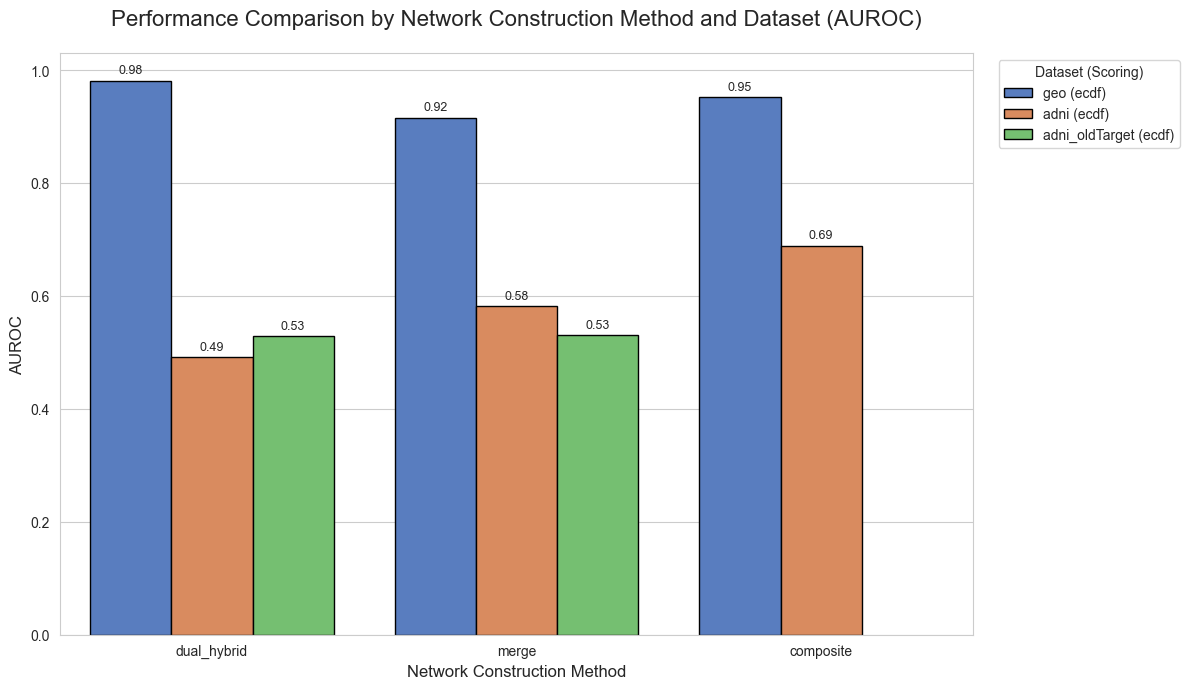

In [87]:
plot_grouped_performance(results_df, metric_name="AUROC")

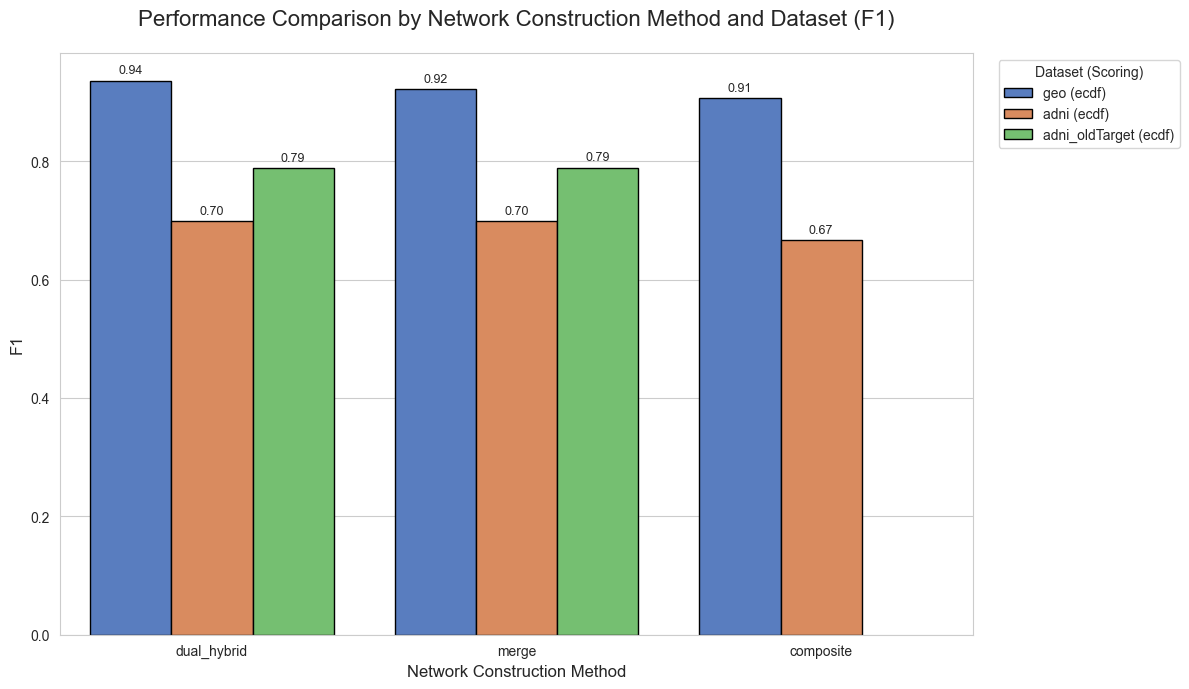

In [89]:
plot_grouped_performance(results_df, metric_name="F1")

In [90]:
results_df

,Method,Dataset,Scoring,Model,Accuracy,F1,AUROC,AUPRC,Condition
0,dual_hybrid,geo,ecdf,gat,0.915493,0.936170,0.981383,0.990566,geo (ecdf)
1,merge,geo,ecdf,gat,0.887324,0.921569,0.915780,0.947312,geo (ecdf)
2,composite,geo,ecdf,gat,0.873239,0.907216,0.952128,0.974022,geo (ecdf)
3,dual_hybrid,adni,ecdf,gat,0.536232,0.698113,0.491554,0.572527,adni (ecdf)
4,merge,adni,ecdf,gat,0.536232,0.698113,0.581926,0.612138,adni (ecdf)
5,composite,adni,ecdf,gat,0.637681,0.666667,0.689076,0.734090,adni (ecdf)
6,dual_hybrid,adni_oldTarget,ecdf,gat,0.660714,0.788889,0.528627,0.660283,adni_oldTarget (ecdf)
7,merge,adni_oldTarget,ecdf,gat,0.651786,0.789189,0.531085,0.682233,adni_oldTarget (ecdf)


In [91]:
df_melted = results_df.melt(
        id_vars=['Dataset', 'Scoring', 'Model', 'Method'], 
        value_vars=['Accuracy', 'F1', 'AUROC', 'AUPRC'],
        var_name='Metric', 
        value_name='Score'
    )
df_melted

,Dataset,Scoring,Model,Method,Metric,Score
0,geo,ecdf,gat,dual_hybrid,Accuracy,0.915493
1,geo,ecdf,gat,merge,Accuracy,0.887324
2,geo,ecdf,gat,composite,Accuracy,0.873239
3,adni,ecdf,gat,dual_hybrid,Accuracy,0.536232
4,adni,ecdf,gat,merge,Accuracy,0.536232
5,adni,ecdf,gat,composite,Accuracy,0.637681
6,adni_oldTarget,ecdf,gat,dual_hybrid,Accuracy,0.660714
7,adni_oldTarget,ecdf,gat,merge,Accuracy,0.651786
8,geo,ecdf,gat,dual_hybrid,F1,0.936170
9,geo,ecdf,gat,merge,F1,0.921569


In [95]:
def plot_metrics(df_melted):
   
    plt.figure(figsize=(16,20))
    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=df_melted, 
        kind="bar",
        x="Dataset", 
        y="Score", 
        hue="Method",
        col="Metric", 
        col_wrap=2,
        palette="muted", 
        height=4, 
        aspect=1.2
    )

    g.set_axis_labels("Dataset", "Score Value")
    g.set_titles("{col_name}")

    # --- ADD LABELS HERE ---
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    # -----------------------

    sns.move_legend(
        g, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
    )

    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300)
    plt.show()

<Figure size 1600x2000 with 0 Axes>

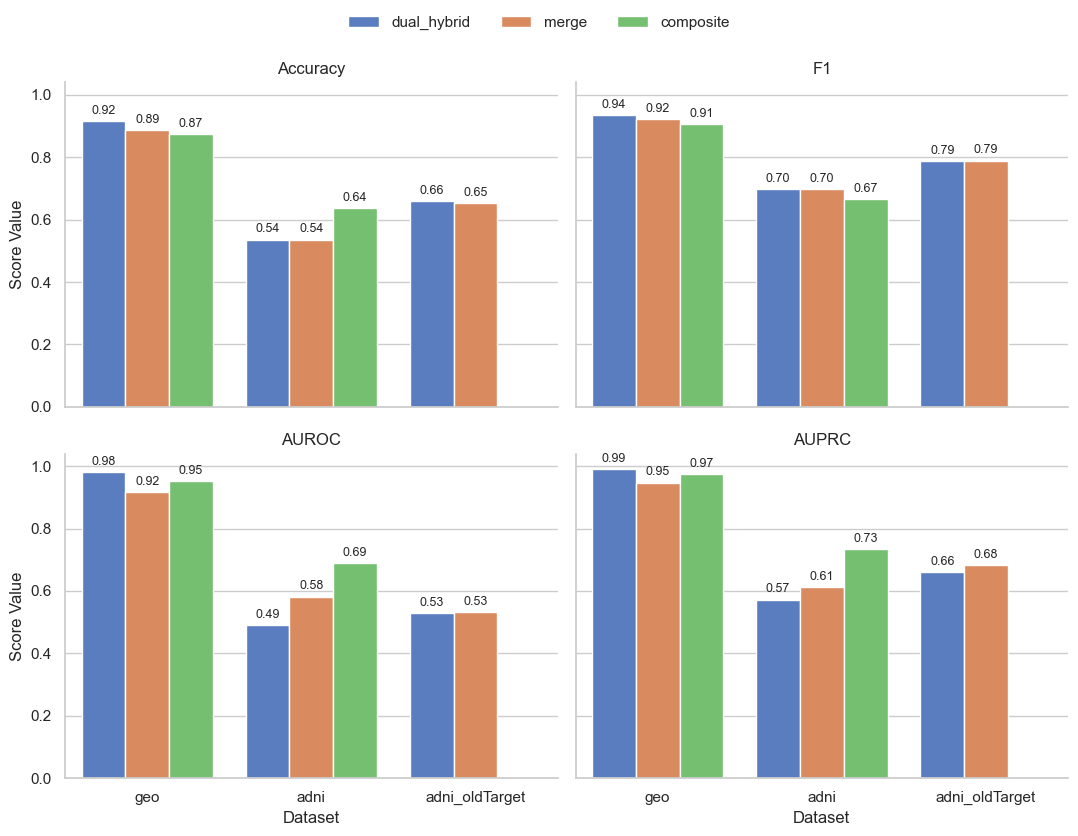

In [96]:
plot_metrics(df_melted)